<a href="https://colab.research.google.com/github/nicolas-pueyo/ia-explicable/blob/main/notebooks/proyecto_iax.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import sys
if 'google.colab' in sys.modules:
  !pip install -q dtreeviz
!pip install interpret six graphviz pydotplus


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 43.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.1/800.1 kB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.6/270.6 kB 19.6 MB/s eta 0:00:00
  Created wheel for dash-cytoscape: filename=dash_cytoscape-1.0.2-py3-none-any.whl size=4010811 sha256=f15b3bdcb7441f598ea6b3fe1ebb26544f058956176594ad4675083f0c0f5487


Carga de datos

In [3]:
import pandas as pd

base = "https://raw.githubusercontent.com/nicolas-pueyo/ia-explicable/main/data/"
train = pd.read_csv(base + "train.csv")
test = pd.read_csv(base + "test.csv")
dic = pd.read_excel(base + "data-dictionary.xlsx")

id_col = 'row_id'
target_col = 'payment_difficulty_next_month'

credit_y = train[target_col]
credit_X = train.drop(columns=[target_col, id_col])

categorical_cols = [
    'sex',
    'education',
    'marital_status',
    'repayment_assistance_plan'
]

numeric_cols = [col for col in credit_X.columns if col not in categorical_cols]

Preprocesado

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

tree_clf = DecisionTreeClassifier(random_state=42)

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", tree_clf)
])

Búsqueda de hiperparámetros

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'classifier__max_depth': [3, 4], # valores pequeños para interpretabilidad
    'classifier__min_samples_leaf': [20, 50, 100],
    'classifier__criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    refit=True # Entrena un modelo final con los mejores parámetros utilizando todo el conjunto de entrenamiento
)

grid_search.fit(credit_X, credit_y)
best_pipeline = grid_search.best_estimator_

In [6]:
# Mostrar los mejores hiperparámetros encontrados por el Grid Search
print("==================================================")
print("  MEJORES HIPERPARÁMETROS SELECCIONADOS POR CV")
print("==================================================")
for param, value in grid_search.best_params_.items():
    # Limpiamos el prefijo del clasificador para que sea más legible
    clean_param = param.replace('classifier__', '')
    print(f"-> {clean_param}: {value}")
print("==================================================")
print(f"Mejor puntuación obtenida (ROC AUC): {grid_search.best_score_:.4f}")

  MEJORES HIPERPARÁMETROS SELECCIONADOS POR CV
-> criterion: entropy
-> max_depth: 4
-> min_samples_leaf: 100
Mejor puntuación obtenida (ROC AUC): 0.7473


Resultados de la búsqueda

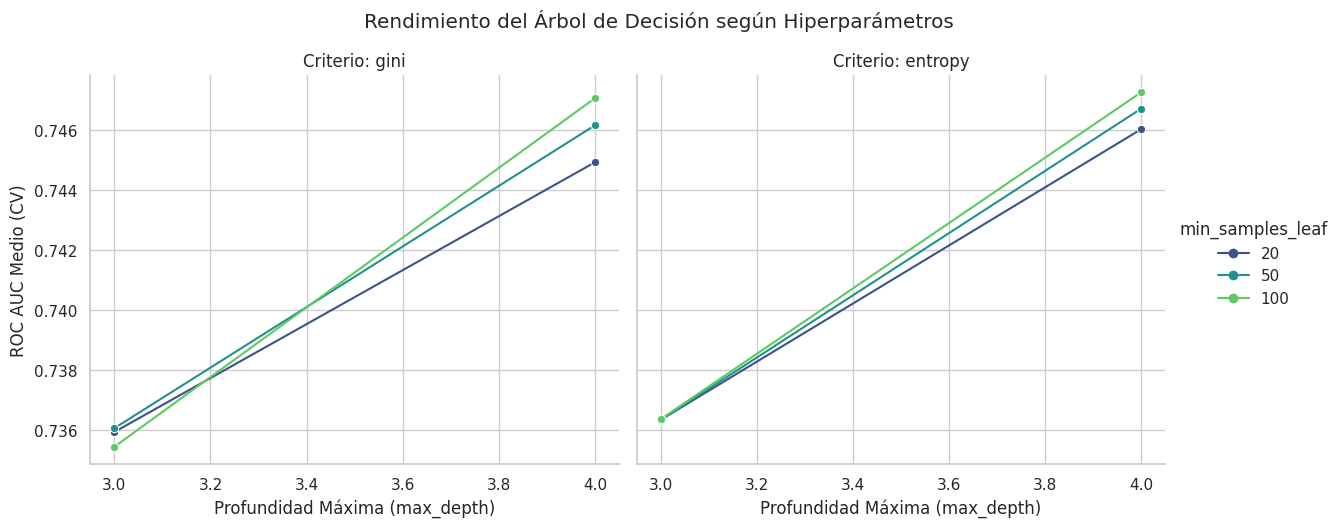

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

results_df = pd.DataFrame(grid_search.cv_results_)

results_df['max_depth'] = results_df['param_classifier__max_depth'].astype(int)
results_df['min_samples_leaf'] = results_df['param_classifier__min_samples_leaf'].astype(str)
results_df['criterion'] = results_df['param_classifier__criterion']
results_df['roc_auc'] = results_df['mean_test_score']

sns.set_theme(style="whitegrid")
g = sns.relplot(
    data=results_df,
    kind="line",
    x="max_depth",
    y="roc_auc",
    hue="min_samples_leaf",
    col="criterion",
    marker="o",
    height=5,
    aspect=1.2,
    palette="viridis"
)

g.set_axis_labels("Profundidad Máxima (max_depth)", "ROC AUC Medio (CV)")
g.set_titles("Criterio: {col_name}")
g.fig.suptitle("Rendimiento del Árbol de Decisión según Hiperparámetros", y=1.05)

plt.savefig("hyperparameter_tuning.png", dpi=300, bbox_inches="tight")
plt.show()

Árbol resultante

Reglas lógicas del modelo óptimo:
|--- latest_repayment_status <= 0.50
|   |--- payment_to_bill_ratio_6m <= 0.11
|   |   |--- zero_payment_months_6m <= 3.50
|   |   |   |--- age <= 24.50
|   |   |   |   |--- class: 0
|   |   |   |--- age >  24.50
|   |   |   |   |--- class: 0
|   |   |--- zero_payment_months_6m >  3.50
|   |   |   |--- payment_to_bill_ratio_6m <= 0.01
|   |   |   |   |--- class: 0
|   |   |   |--- payment_to_bill_ratio_6m >  0.01
|   |   |   |   |--- class: 0
|   |--- payment_to_bill_ratio_6m >  0.11
|   |   |--- zero_payment_months_6m <= 2.50
|   |   |   |--- payment_to_bill_ratio_6m <= 0.25
|   |   |   |   |--- class: 0
|   |   |   |--- payment_to_bill_ratio_6m >  0.25
|   |   |   |   |--- class: 0
|   |   |--- zero_payment_months_6m >  2.50
|   |   |   |--- payment_to_bill_ratio_6m <= 1.29
|   |   |   |   |--- class: 0
|   |   |   |--- payment_to_bill_ratio_6m >  1.29
|   |   |   |   |--- class: 0
|--- latest_repayment_status >  0.50
|   |--- payment_to_bill_ratio_6

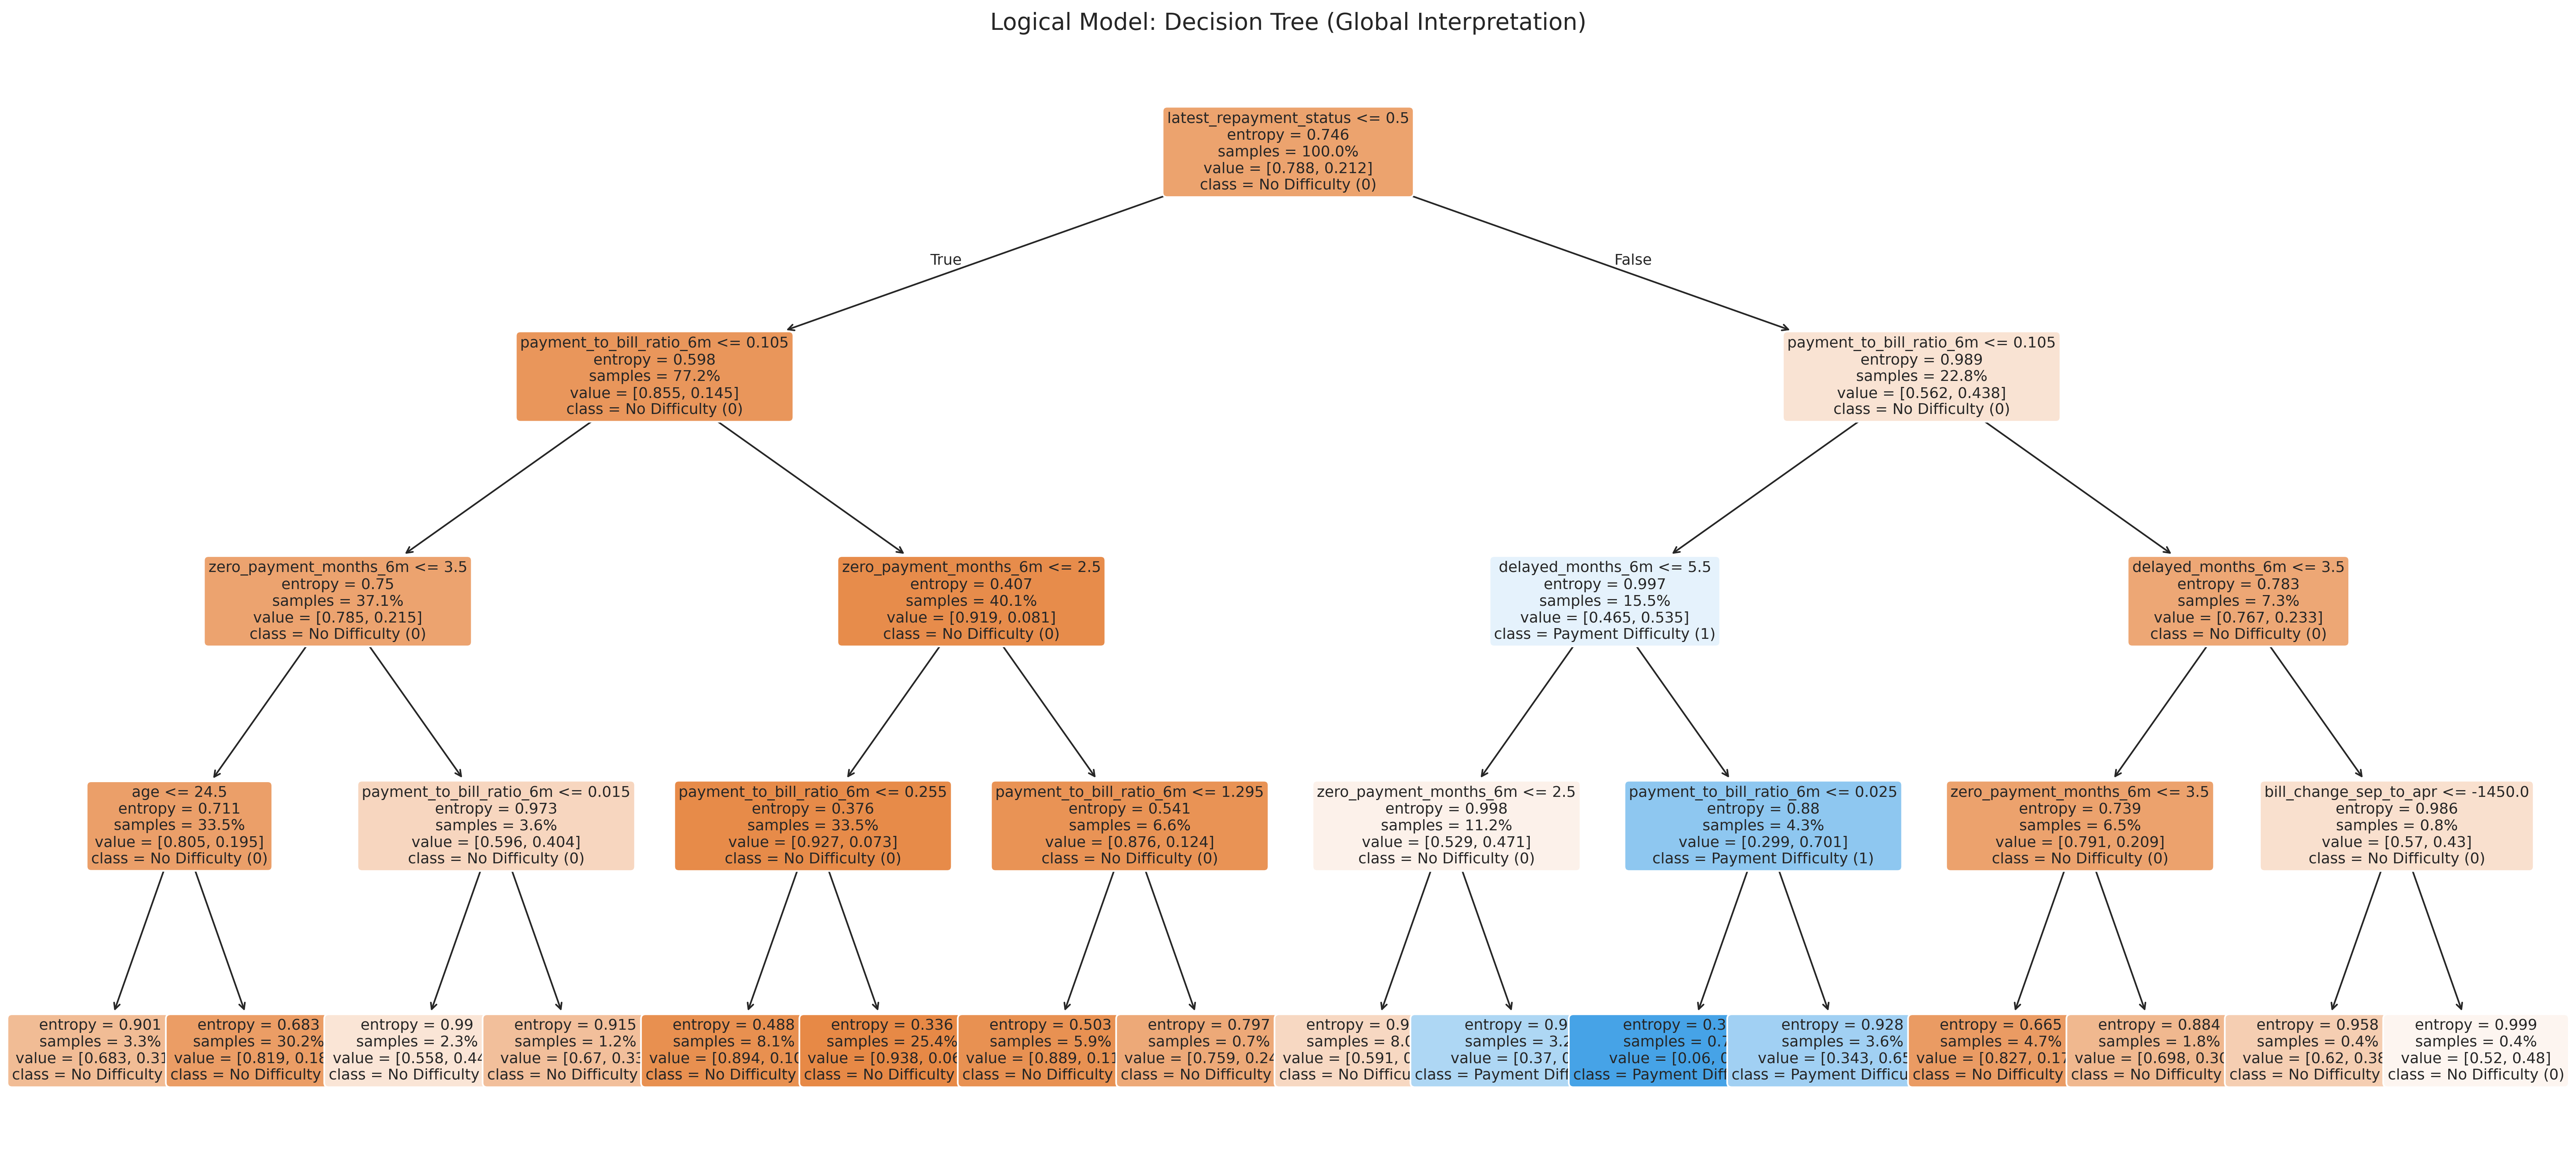

In [8]:
from sklearn.tree import export_text, plot_tree

fitted_tree = best_pipeline.named_steps["classifier"]
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
clean_feature_names = [col.replace("cat__", "").replace("num__", "") for col in feature_names]

print("Reglas lógicas del modelo óptimo:")
print(export_text(fitted_tree, feature_names=clean_feature_names))

plt.figure(figsize=(22, 10), dpi=300)
plot_tree(
    fitted_tree,
    feature_names=clean_feature_names,
    class_names=["No Difficulty (0)", "Payment Difficulty (1)"],
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=True,
    proportion=True,
)
plt.title("Logical Model: Decision Tree (Global Interpretation)", fontsize=14)
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=300, bbox_inches="tight")

Métricas de rendimiento

In [9]:
scoring_metrics = ["accuracy", "roc_auc", "f1", "balanced_accuracy"]
cv_results = cross_validate(
    best_pipeline,
    credit_X,
    credit_y,
    cv=cv,
    scoring=scoring_metrics,
    return_train_score=False
)

for metric in scoring_metrics:
    mean_val = cv_results[f"test_{metric}"].mean()
    std_val = cv_results[f"test_{metric}"].std()
    print(f"{metric}: {mean_val:.4f} (+/- {std_val:.4f})")

accuracy: 0.8128 (+/- 0.0022)
roc_auc: 0.7473 (+/- 0.0050)
f1: 0.3498 (+/- 0.0095)
balanced_accuracy: 0.6026 (+/- 0.0040)


Interpretacion global

In [10]:
fitted_tree = best_pipeline.named_steps["classifier"]
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
clean_feature_names = [col.replace("cat__", "").replace("num__", "") for col in feature_names]

Interpretación local

In [11]:
from interpret.glassbox import ClassificationTree
from interpret import show
import pandas as pd
import numpy as np

# Extraer los hiperparámetros óptimos que encontró Grid Search
best_params = grid_search.best_params_
opt_max_depth = best_params['classifier__max_depth']
opt_min_samples_leaf = best_params['classifier__min_samples_leaf']
opt_criterion = best_params['classifier__criterion']

# Transformar el conjunto de entrenamiento
X_train_trans = best_pipeline.named_steps["preprocessor"].transform(credit_X)
if hasattr(X_train_trans, "toarray"):
    X_train_trans = X_train_trans.toarray()

X_train_df = pd.DataFrame(X_train_trans, columns=clean_feature_names)

# Entrenar el árbol de InterpretML con la configuración óptima
interpret_tree = ClassificationTree(
    max_depth=opt_max_depth,
    min_samples_leaf=opt_min_samples_leaf,
    criterion=opt_criterion,
    random_state=42
)
interpret_tree.fit(X_train_df, credit_y)

# Obtener las predicciones del modelo para identificar aciertos y errores
y_pred = best_pipeline.predict(credit_X)

# Definir las condiciones para cada uno de los 4 casos solicitados
mask_c0_correct = (y_pred == 0) & (credit_y == 0)
mask_c0_incorrect = (y_pred == 1) & (credit_y == 0)
mask_c1_correct = (y_pred == 1) & (credit_y == 1)
mask_c1_incorrect = (y_pred == 0) & (credit_y == 1)

# Seleccionar la primera instancia que cumpla cada condición
idx_c0_correct = credit_X[mask_c0_correct].index[0]
idx_c0_incorrect = credit_X[mask_c0_incorrect].index[0]
idx_c1_correct = credit_X[mask_c1_correct].index[0]
idx_c1_incorrect = credit_X[mask_c1_incorrect].index[0]

# Crear un DataFrame con las 4 instancias seleccionadas y renombrar el índice para el gráfico
instancias_locales = credit_X.loc[[idx_c0_correct, idx_c0_incorrect, idx_c1_correct, idx_c1_incorrect]].copy()
instancias_locales.index = [
    'Clase 0 - Prediccion Correcta (True Neg)',
    'Clase 0 - Prediccion Incorrecta (False Pos)',
    'Clase 1 - Prediccion Correcta (True Pos)',
    'Clase 1 - Prediccion Incorrecta (False Neg)'
]

y_locales = credit_y.loc[[idx_c0_correct, idx_c0_incorrect, idx_c1_correct, idx_c1_incorrect]]
y_locales.index = instancias_locales.index

# Transformar las instancias pasando por el preprocesador
X_locales_trans = best_pipeline.named_steps["preprocessor"].transform(instancias_locales)
if hasattr(X_locales_trans, "toarray"):
    X_locales_trans = X_locales_trans.toarray()

X_locales_df = pd.DataFrame(X_locales_trans, columns=clean_feature_names, index=instancias_locales.index)

# Generar y mostrar la explicación local (Widget con desplegable para los 4 casos)
tree_local = interpret_tree.explain_local(X_locales_df, y_locales, name='Comparativa de Predicciones Locales')
show(tree_local)

In [17]:
train["payment_difficulty_next_month"].value_counts(normalize=True)

,proportion
payment_difficulty_next_month,
0,0.78788
1,0.21212
